In [4]:
# Seasonal Agriculture Performance Analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")


Libraries imported successfully!


In [5]:
# Upload the agriculture dataset

from google.colab import files

uploaded = files.upload()

Saving seasonal_agriculture_performance_dataset.csv to seasonal_agriculture_performance_dataset (1).csv


In [6]:
# Load the dataset

file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

print("Dataset loaded successfully!")
print("File name:", file_name)

Dataset loaded successfully!
File name: seasonal_agriculture_performance_dataset (1).csv


In [7]:
# Display the first 5 rows

df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [8]:
# Basic information about the dataset

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Number of rows: 4000
Number of columns: 28

Column Names:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3  

In [9]:
# Statistical summary of numerical columns

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [10]:
# Check missing values

missing = df.isnull().sum()

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": (missing / len(df) * 100).round(2)
})

missing_table[missing_table["Missing Values"] > 0]

,Missing Values,Percentage
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


In [11]:
# Handle missing values using median

df["Rainfall_mm"] = df["Rainfall_mm"].fillna(df["Rainfall_mm"].median())

df["Soil_Moisture_pct"] = df["Soil_Moisture_pct"].fillna(
    df["Soil_Moisture_pct"].median()
)

df["Yield_Tonnes_Ha"] = df["Yield_Tonnes_Ha"].fillna(
    df["Yield_Tonnes_Ha"].median()
)

print("Missing values handled successfully!")

Missing values handled successfully!


In [12]:
# Verify that no missing values remain

df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,0
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [13]:
# Check for duplicate rows

duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [14]:
# Check minimum values of numerical columns

df.describe().T[["min", "max"]]

,min,max
Farm_Area_Hectares,0.500,15.00
Rainfall_mm,80.000,1395.20
Avg_Temperature_C,16.200,39.70
Humidity_pct,25.000,95.00
Sunlight_Hours_Day,3.500,11.00
Soil_pH,5.200,8.40
Soil_Moisture_pct,8.000,47.00
Nitrogen_kg_ha,40.000,220.00
Phosphorus_kg_ha,15.000,120.00
Potassium_kg_ha,30.000,200.00


In [15]:
# Check the number of farms in each season

season_counts = df["Season"].value_counts()

print(season_counts)

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


In [16]:
# Compare agricultural performance across seasons

season_summary = df.groupby("Season")[
    ["Yield_Tonnes_Ha",
     "Production_Tonnes",
     "Revenue_INR",
     "Profit_INR"]
].mean().round(2)

season_summary

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR
Season,,,,
Kharif,5.63,46.31,710719.06,178914.65
Rabi,5.04,41.49,601526.05,87689.47
Zaid,4.64,38.89,519171.90,-24804.82


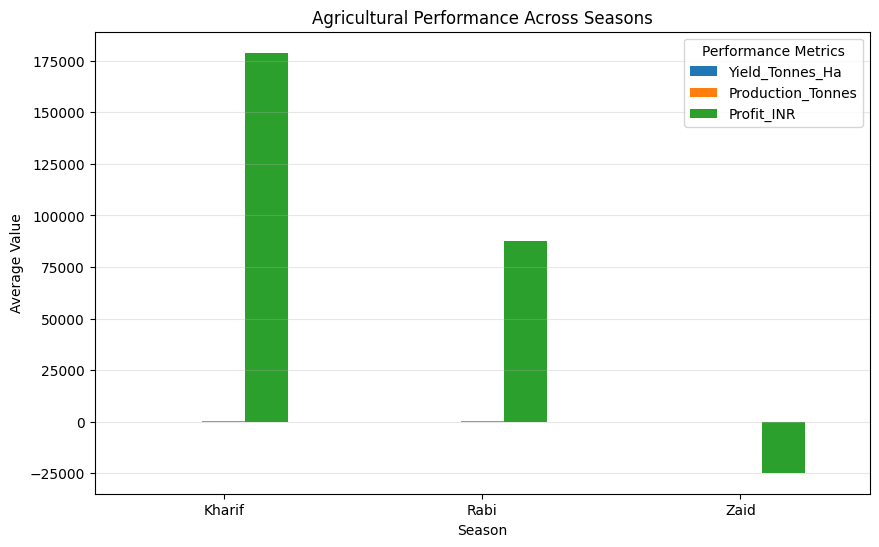

In [17]:
# Visualize seasonal agricultural performance

season_summary[["Yield_Tonnes_Ha", "Production_Tonnes", "Profit_INR"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Agricultural Performance Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.legend(title="Performance Metrics")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [18]:
# Environmental conditions across seasons

environment_summary = df.groupby("Season")[
    ["Rainfall_mm",
     "Avg_Temperature_C",
     "Humidity_pct",
     "Sunlight_Hours_Day",
     "Soil_Moisture_pct"]
].mean().round(2)

environment_summary

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,849.20,28.45,71.81,6.79,31.15
Rabi,437.62,23.49,57.89,7.59,24.07
Zaid,304.65,31.04,52.01,8.18,19.28


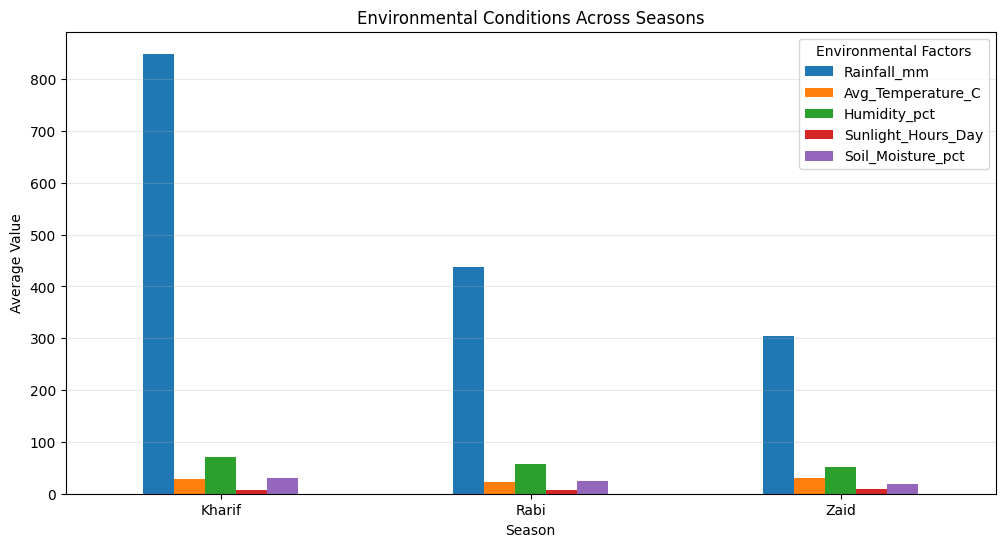

In [20]:
# Visualize environmental conditions across seasons

environment_summary.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Environmental Conditions Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.legend(title="Environmental Factors")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [19]:
# Resource usage across seasons

resource_summary = df.groupby("Season")[
    ["Water_Used_m3",
     "Water_Efficiency_t_per_1000m3",
     "Fertilizer_kg_ha",
     "Pesticide_Litre_ha"]
].mean().round(2)

resource_summary

,Water_Used_m3,Water_Efficiency_t_per_1000m3,Fertilizer_kg_ha,Pesticide_Litre_ha
Season,,,,
Kharif,6102.20,5.89,187.08,5.08
Rabi,5846.99,5.19,185.41,5.02
Zaid,6419.89,4.41,184.64,5.17


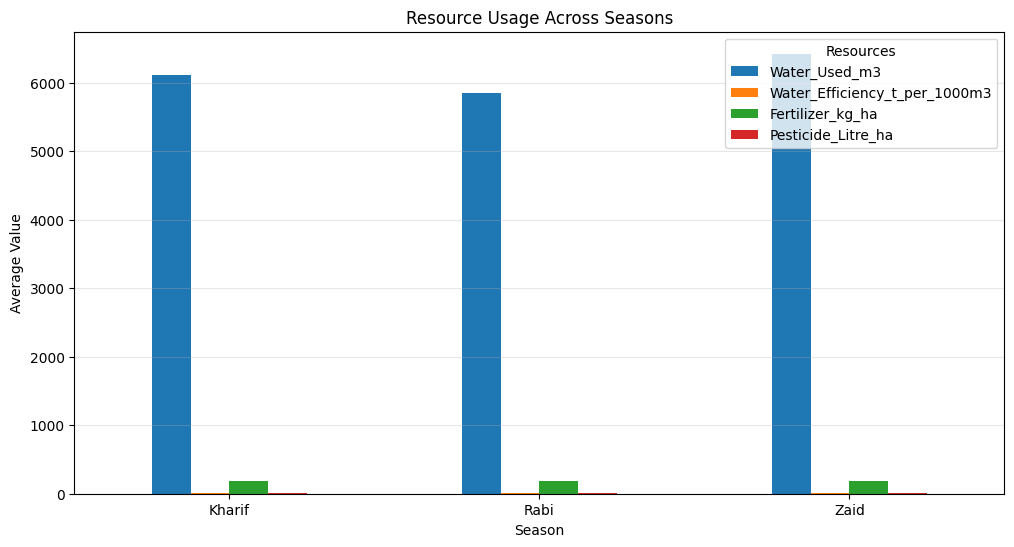

In [21]:
# Visualize resource usage across seasons

resource_summary.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Resource Usage Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.legend(title="Resources")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [22]:
# Average yield by crop

crop_yield = df.groupby("Crop")["Yield_Tonnes_Ha"] \
              .mean() \
              .sort_values(ascending=False) \
              .round(2)

crop_yield

,Yield_Tonnes_Ha
Crop,
Sugarcane,46.64
Maize,2.71
Rice,2.43
Wheat,2.11
Chilli,1.54
Groundnut,1.32
Cotton,1.23
Pulses,0.92


In [23]:
# Compare production and profit by crop

crop_economics = df.groupby("Crop")[
    ["Production_Tonnes", "Revenue_INR", "Profit_INR"]
].mean().sort_values("Profit_INR", ascending=False).round(2)

crop_economics

,Production_Tonnes,Revenue_INR,Profit_INR
Crop,,,
Sugarcane,392.41,1371980.11,817187.99
Chilli,12.38,1276777.23,750878.34
Cotton,9.40,639423.08,124546.92
Groundnut,9.66,542935.50,44858.12
Pulses,7.40,528465.87,-4238.05
Maize,21.78,457067.99,-83978.33
Rice,19.29,423615.26,-102213.50
Wheat,16.85,400104.89,-123398.34


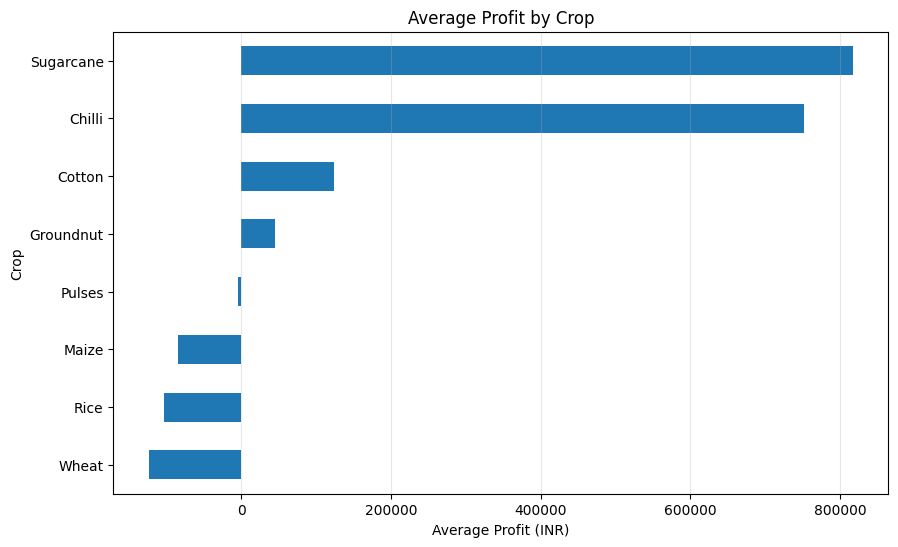

In [24]:
# Visualize average profit by crop

crop_economics["Profit_INR"].sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Average Profit by Crop")
plt.xlabel("Average Profit (INR)")
plt.ylabel("Crop")
plt.grid(axis="x", alpha=0.3)

plt.show()

In [25]:
# Economic performance across seasons

economic_summary = df.groupby("Season")[
    ["Total_Cost_INR",
     "Revenue_INR",
     "Profit_INR"]
].mean().round(2)

economic_summary

,Total_Cost_INR,Revenue_INR,Profit_INR
Season,,,
Kharif,531804.41,710719.06,178914.65
Rabi,513836.58,601526.05,87689.47
Zaid,543976.73,519171.90,-24804.82


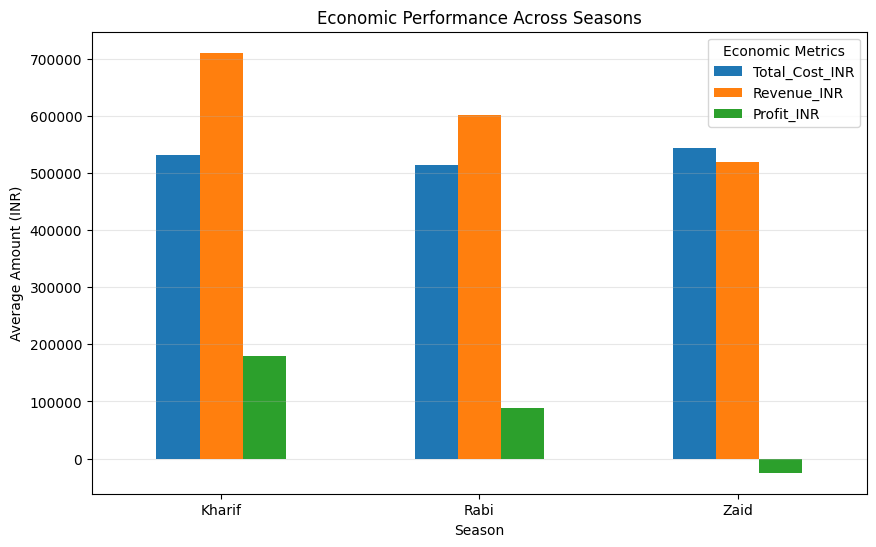

In [26]:
# Visualize economic performance across seasons

economic_summary.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Economic Performance Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Amount (INR)")
plt.xticks(rotation=0)
plt.legend(title="Economic Metrics")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [27]:
# Average agricultural performance by state

state_summary = df.groupby("State")[
    ["Yield_Tonnes_Ha",
     "Production_Tonnes",
     "Revenue_INR",
     "Profit_INR"]
].mean().sort_values("Profit_INR", ascending=False).round(2)

state_summary

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR
State,,,,
Punjab,6.12,52.23,686225.70,136025.64
Maharashtra,5.02,43.98,650032.67,135428.86
Karnataka,5.69,47.73,653426.18,119422.34
Tamil Nadu,4.88,40.84,629093.42,117744.75
Gujarat,5.66,48.33,654692.86,117568.24
Telangana,5.04,39.25,628784.53,108829.62
Madhya Pradesh,4.99,37.56,597558.36,86840.76
Andhra Pradesh,4.63,36.91,606663.66,73453.53


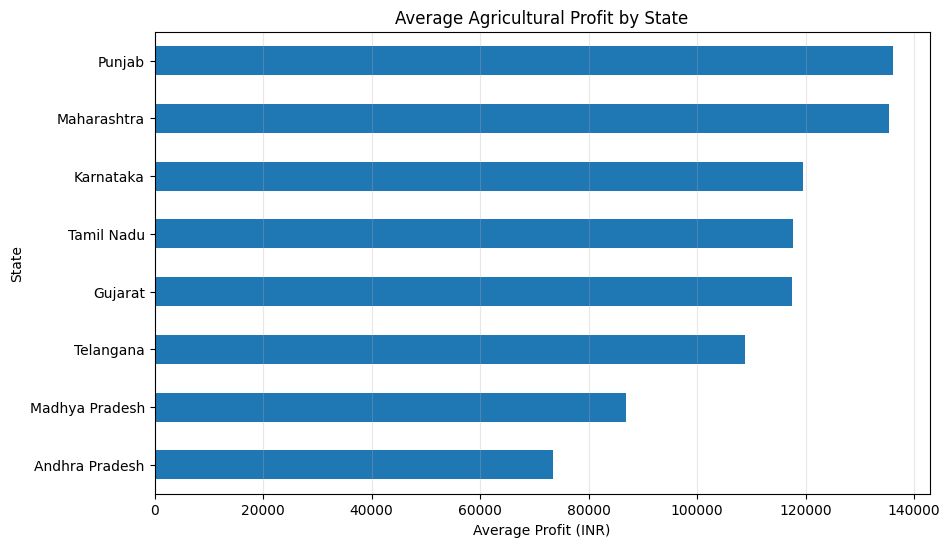

In [28]:
# Visualize average profit by state

state_summary["Profit_INR"].sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Average Agricultural Profit by State")
plt.xlabel("Average Profit (INR)")
plt.ylabel("State")
plt.grid(axis="x", alpha=0.3)

plt.show()

In [29]:
# Average agricultural performance by district

district_summary = df.groupby("District")[
    ["Yield_Tonnes_Ha",
     "Production_Tonnes",
     "Revenue_INR",
     "Profit_INR"]
].mean().sort_values("Profit_INR", ascending=False).round(2)

district_summary

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR
District,,,,
Warangal,5.50,46.27,703386.39,166449.96
Nalgonda,5.80,47.54,651104.56,131125.84
Raichur,4.94,39.28,637352.42,125172.70
Rajkot,6.02,54.83,648998.32,119463.28
Guntur,5.47,44.62,635094.22,116411.42
Erode,4.18,37.77,630542.70,102079.57
Nashik,4.86,36.74,614387.90,94910.17
Indore,4.88,38.56,630401.75,90421.34
Ludhiana,5.80,45.16,621442.69,87590.83


In [30]:
# Top 10 and bottom 10 districts by average profit

top_10_districts = district_summary.head(10)
bottom_10_districts = district_summary.tail(10)

print("TOP 10 DISTRICTS BY AVERAGE PROFIT")
display(top_10_districts)

print("\nBOTTOM 10 DISTRICTS BY AVERAGE PROFIT")
display(bottom_10_districts)

TOP 10 DISTRICTS BY AVERAGE PROFIT


,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR
District,,,,
Warangal,5.50,46.27,703386.39,166449.96
Nalgonda,5.80,47.54,651104.56,131125.84
Raichur,4.94,39.28,637352.42,125172.70
Rajkot,6.02,54.83,648998.32,119463.28
Guntur,5.47,44.62,635094.22,116411.42
Erode,4.18,37.77,630542.70,102079.57
Nashik,4.86,36.74,614387.90,94910.17
Indore,4.88,38.56,630401.75,90421.34
Ludhiana,5.80,45.16,621442.69,87590.83



BOTTOM 10 DISTRICTS BY AVERAGE PROFIT


,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR
District,,,,
Warangal,5.50,46.27,703386.39,166449.96
Nalgonda,5.80,47.54,651104.56,131125.84
Raichur,4.94,39.28,637352.42,125172.70
Rajkot,6.02,54.83,648998.32,119463.28
Guntur,5.47,44.62,635094.22,116411.42
Erode,4.18,37.77,630542.70,102079.57
Nashik,4.86,36.74,614387.90,94910.17
Indore,4.88,38.56,630401.75,90421.34
Ludhiana,5.80,45.16,621442.69,87590.83


In [31]:
# Check the number of districts and their profit values

print("Number of districts:", len(district_summary))
print("\nLowest 10 district profits:")
display(district_summary.sort_values("Profit_INR").head(10))

print("\nHighest 10 district profits:")
display(district_summary.sort_values("Profit_INR", ascending=False).head(10))

Number of districts: 10

Lowest 10 district profits:


,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR
District,,,,
Krishna,4.85,40.52,600329.53,78240.90
Ludhiana,5.80,45.16,621442.69,87590.83
Indore,4.88,38.56,630401.75,90421.34
Nashik,4.86,36.74,614387.90,94910.17
Erode,4.18,37.77,630542.70,102079.57
Guntur,5.47,44.62,635094.22,116411.42
Rajkot,6.02,54.83,648998.32,119463.28
Raichur,4.94,39.28,637352.42,125172.70
Nalgonda,5.80,47.54,651104.56,131125.84



Highest 10 district profits:


,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR
District,,,,
Warangal,5.50,46.27,703386.39,166449.96
Nalgonda,5.80,47.54,651104.56,131125.84
Raichur,4.94,39.28,637352.42,125172.70
Rajkot,6.02,54.83,648998.32,119463.28
Guntur,5.47,44.62,635094.22,116411.42
Erode,4.18,37.77,630542.70,102079.57
Nashik,4.86,36.74,614387.90,94910.17
Indore,4.88,38.56,630401.75,90421.34
Ludhiana,5.80,45.16,621442.69,87590.83


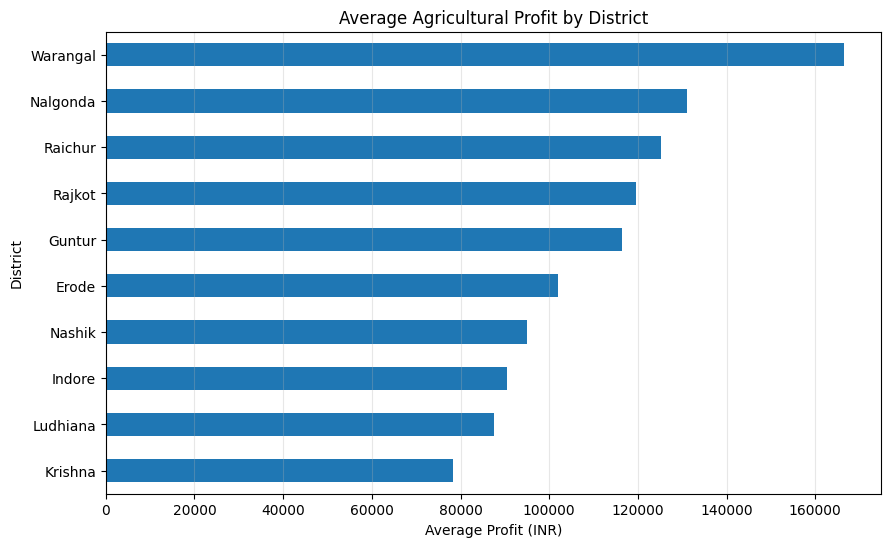

In [32]:
# District-wise average profit

district_profit = district_summary["Profit_INR"].sort_values()

district_profit.plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Average Agricultural Profit by District")
plt.xlabel("Average Profit (INR)")
plt.ylabel("District")
plt.grid(axis="x", alpha=0.3)

plt.show()

In [33]:
# Correlation analysis

numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr().round(2)

correlation

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Farm_Area_Hectares,1.00,0.01,0.04,0.00,0.00,0.01,0.00,0.01,-0.01,0.00,...,0.02,0.03,0.20,-0.02,0.96,0.54,0.12,0.58,0.03,0.03
Rainfall_mm,0.01,1.00,0.20,0.52,-0.36,0.02,0.51,0.01,0.02,0.03,...,-0.02,0.03,0.02,0.00,0.01,0.10,0.11,0.00,0.06,0.62
Avg_Temperature_C,0.04,0.20,1.00,0.14,-0.03,0.03,0.08,0.02,0.01,0.02,...,-0.03,0.01,0.01,0.00,0.04,0.03,0.01,0.02,0.01,0.25
Humidity_pct,0.00,0.52,0.14,1.00,-0.30,0.03,0.45,0.00,-0.01,-0.00,...,-0.05,0.01,0.00,0.00,0.01,0.06,0.06,-0.00,0.03,0.55
Sunlight_Hours_Day,0.00,-0.36,-0.03,-0.30,1.00,-0.02,-0.30,0.01,0.00,-0.01,...,0.02,-0.02,-0.02,-0.00,-0.00,-0.05,-0.05,-0.01,-0.02,-0.25
Soil_pH,0.01,0.02,0.03,0.03,-0.02,1.00,0.03,0.01,0.02,-0.02,...,-0.00,-0.02,-0.01,0.02,0.01,-0.01,-0.01,-0.02,-0.01,0.03
Soil_Moisture_pct,0.00,0.51,0.08,0.45,-0.30,0.03,1.00,0.01,0.01,0.01,...,-0.02,0.01,0.00,0.02,0.00,0.08,0.09,0.00,0.03,0.38
Nitrogen_kg_ha,0.01,0.01,0.02,0.00,0.01,0.01,0.01,1.00,0.01,0.01,...,0.01,0.05,0.05,-0.02,0.01,0.08,0.09,0.02,0.05,-0.01
Phosphorus_kg_ha,-0.01,0.02,0.01,-0.01,0.00,0.02,0.01,0.01,1.00,0.00,...,-0.01,0.05,0.03,-0.01,-0.02,0.03,0.05,-0.00,0.06,0.03
Potassium_kg_ha,0.00,0.03,0.02,-0.00,-0.01,-0.02,0.01,0.01,0.00,1.00,...,0.01,0.00,0.00,0.01,0.00,0.03,0.03,0.00,0.01,0.01


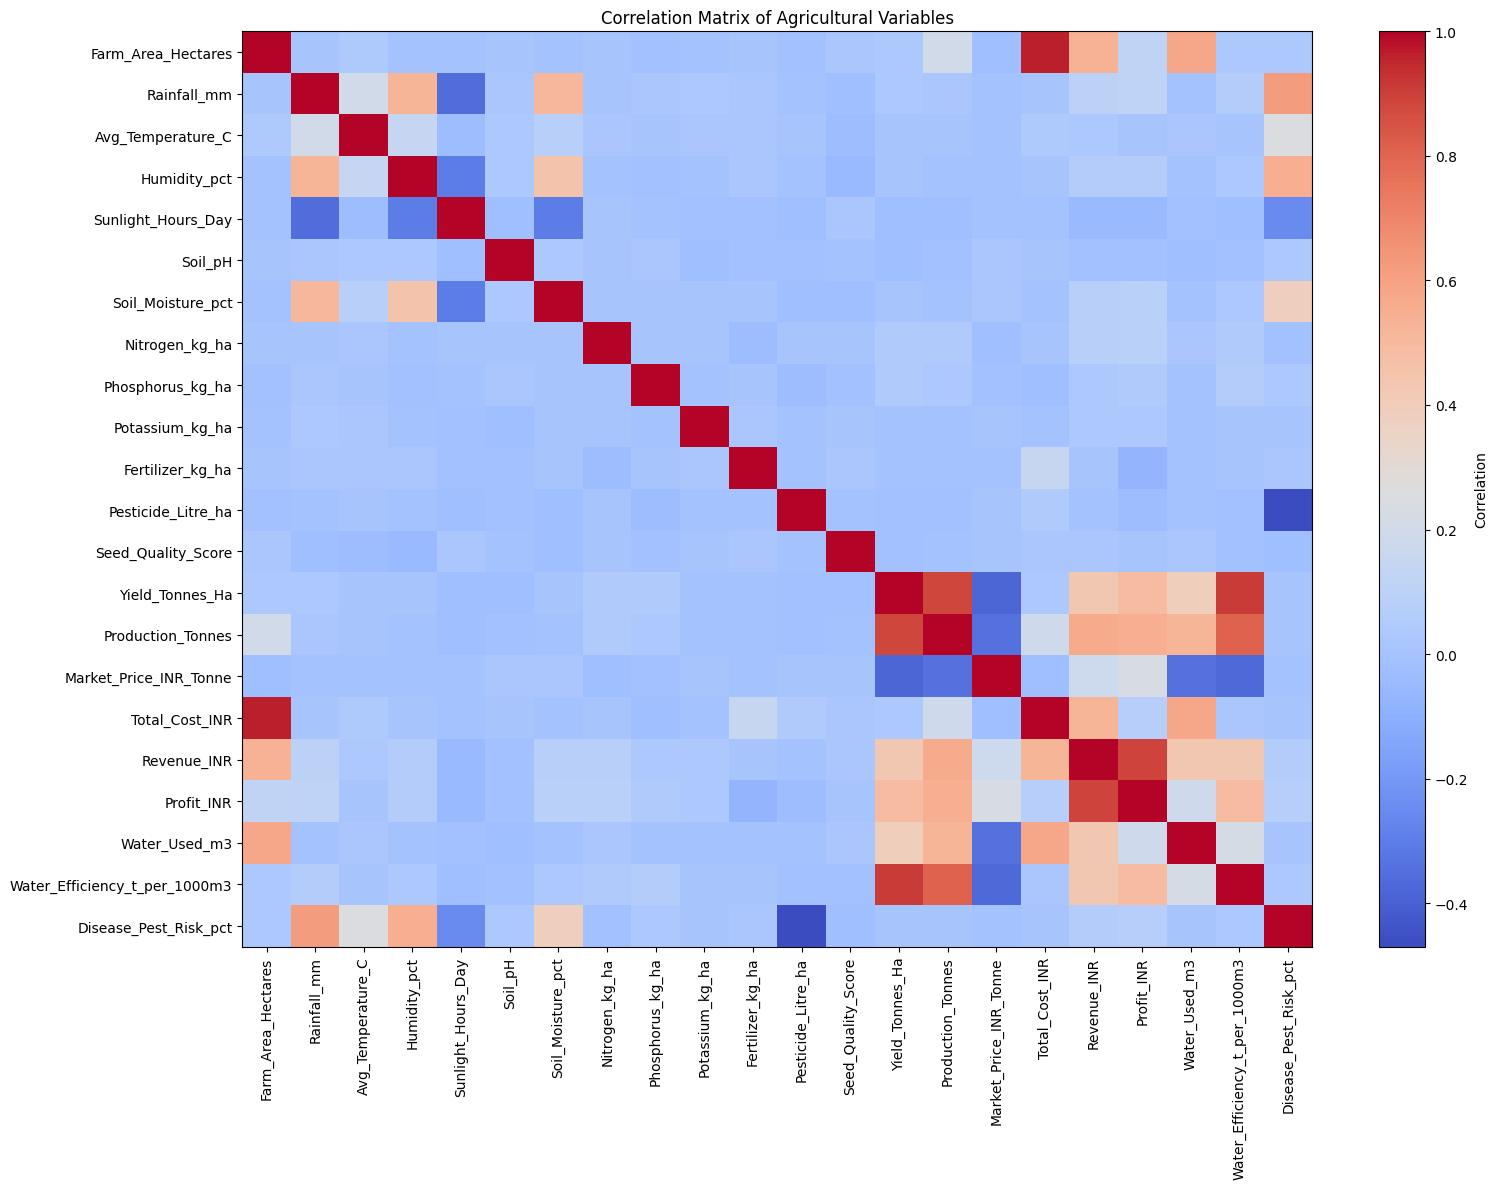

In [34]:
# Correlation heatmap

plt.figure(figsize=(16, 12))

plt.imshow(correlation, cmap="coolwarm", aspect="auto")

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.index)),
    correlation.index
)

plt.title("Correlation Matrix of Agricultural Variables")

plt.tight_layout()
plt.show()

In [35]:
# One-Way ANOVA: Production across Seasons

groups = [
    group["Production_Tonnes"].dropna()
    for name, group in df.groupby("Season")
]

f_stat, p_value = stats.f_oneway(*groups)

print("ANOVA F-statistic:", round(f_stat, 2))
print("ANOVA p-value:", p_value)

if p_value < 0.05:
    print("Result: Production differs significantly across seasons.")
else:
    print("Result: No statistically significant difference in production across seasons.")

ANOVA F-statistic: 1.03
ANOVA p-value: 0.3584517394101745
Result: No statistically significant difference in production across seasons.


In [36]:
# One-Way ANOVA: Yield across Seasons

yield_groups = [
    group["Yield_Tonnes_Ha"].dropna()
    for name, group in df.groupby("Season")
]

f_stat_yield, p_value_yield = stats.f_oneway(*yield_groups)

print("Yield ANOVA F-statistic:", round(f_stat_yield, 2))
print("Yield ANOVA p-value:", p_value_yield)

if p_value_yield < 0.05:
    print("Result: Yield differs significantly across seasons.")
else:
    print("Result: No statistically significant difference in yield across seasons.")

Yield ANOVA F-statistic: 1.54
Yield ANOVA p-value: 0.21367813841792296
Result: No statistically significant difference in yield across seasons.


In [37]:
# Irrigation Method Analysis

irrigation_summary = df.groupby("Irrigation_Method")[
    ["Yield_Tonnes_Ha",
     "Water_Used_m3",
     "Water_Efficiency_t_per_1000m3",
     "Profit_INR"]
].mean().sort_values("Profit_INR", ascending=False).round(2)

irrigation_summary

,Yield_Tonnes_Ha,Water_Used_m3,Water_Efficiency_t_per_1000m3,Profit_INR
Irrigation_Method,,,,
Drip,6.58,5918.75,6.27,219626.00
Sprinkler,5.16,6208.26,4.67,91121.08
Rainfed,4.60,3549.55,7.56,79050.37
Flood,4.86,8026.47,3.44,73354.02


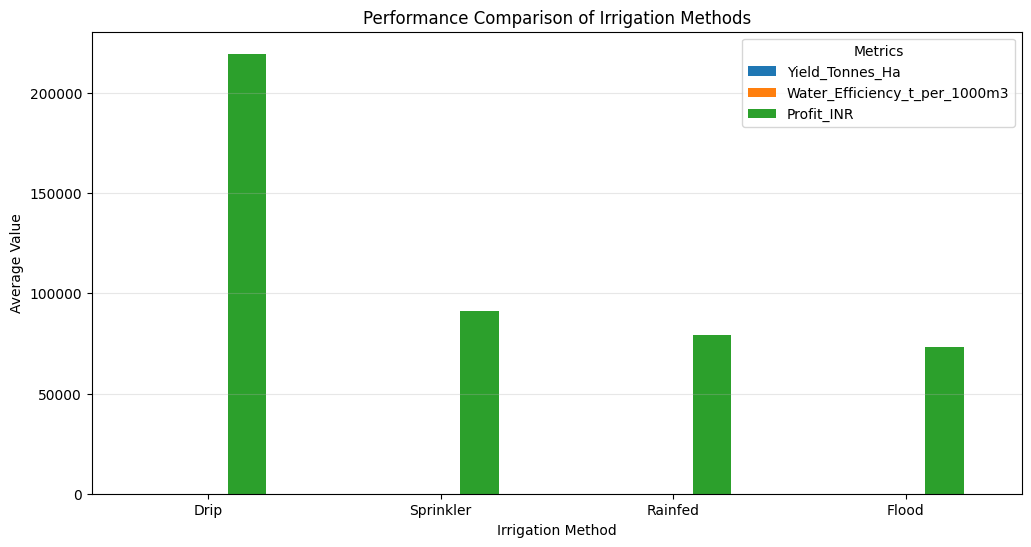

In [38]:
# Irrigation Method Performance Visualization

irrigation_summary[
    ["Yield_Tonnes_Ha",
     "Water_Efficiency_t_per_1000m3",
     "Profit_INR"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Performance Comparison of Irrigation Methods")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.legend(title="Metrics")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [39]:
# Outlier Analysis using the IQR method

Q1 = df["Yield_Tonnes_Ha"].quantile(0.25)
Q3 = df["Yield_Tonnes_Ha"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[
    (df["Yield_Tonnes_Ha"] < lower_limit) |
    (df["Yield_Tonnes_Ha"] > upper_limit)
]

print("Q1:", round(Q1, 2))
print("Q3:", round(Q3, 2))
print("IQR:", round(IQR, 2))
print("Lower Limit:", round(lower_limit, 2))
print("Upper Limit:", round(upper_limit, 2))
print("Number of Yield Outliers:", len(outliers))

Q1: 1.05
Q3: 2.83
IQR: 1.78
Lower Limit: -1.62
Upper Limit: 5.5
Number of Yield Outliers: 302


In [40]:
# Inspect Yield Outliers

outlier_summary = outliers.groupby("Crop")[
    ["Yield_Tonnes_Ha", "Production_Tonnes", "Profit_INR"]
].mean().sort_values("Yield_Tonnes_Ha", ascending=False).round(2)

outlier_summary

,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR
Crop,,,
Sugarcane,48.42,404.77,861686.68
Maize,5.76,41.79,421537.86
Rice,5.68,66.02,751827.50


In [41]:
# Top 10 Highest Yield Records

top_yield = df.sort_values(
    "Yield_Tonnes_Ha",
    ascending=False
)[[
    "Crop",
    "Season",
    "State",
    "Irrigation_Method",
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Profit_INR"
]].head(10)

top_yield

,Crop,Season,State,Irrigation_Method,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR
1715,Sugarcane,Kharif,Gujarat,Drip,101.44,641.10,1608291
3423,Sugarcane,Kharif,Andhra Pradesh,Drip,95.79,1424.40,3330582
3525,Sugarcane,Rabi,Andhra Pradesh,Drip,93.13,648.18,1471529
1464,Sugarcane,Kharif,Gujarat,Drip,91.98,703.65,2216708
3523,Sugarcane,Kharif,Karnataka,Flood,91.46,75.00,234320
2782,Sugarcane,Rabi,Gujarat,Flood,91.32,522.35,1236801
644,Sugarcane,Kharif,Andhra Pradesh,Drip,89.34,668.26,1984818
2847,Sugarcane,Kharif,Telangana,Drip,87.76,672.24,2041678
357,Sugarcane,Rabi,Punjab,Sprinkler,84.75,1249.21,3378879
1178,Sugarcane,Kharif,Karnataka,Drip,83.79,534.58,1200815


In [42]:
# Crop Performance Across Seasons

crop_season_summary = df.groupby(
    ["Crop", "Season"]
)[[
    "Yield_Tonnes_Ha",
    "Revenue_INR",
    "Profit_INR"
]].mean().round(2)

crop_season_summary

Yield_Tonnes_Ha  Revenue_INR  Profit_INR
Crop      Season                                          
Chilli    Kharif             1.73   1494091.73   954380.42
          Rabi               1.47   1140992.37   638572.50
          Zaid               1.20    994429.55   448659.09
Cotton    Kharif             1.37    713739.94   216999.55
          Rabi               1.20    637722.18   107343.59
          Zaid               0.96    469463.91   -53925.34
Groundnut Kharif             1.48    594414.86   108265.44
          Rabi               1.23    505760.27    10416.54
          Zaid               1.04    480796.57   -68872.50
Maize     Kharif             2.97    486047.01   -39332.67
          Rabi               2.60    454728.04   -89133.40
          Zaid               2.29    382831.30  -194049.17
Pulses    Kharif             1.04    590276.29    43338.90
          Rabi               0.88    515813.30   -14309.14
          Zaid               0.67    351609.31  -139227.81
Rice      Kharif             2.70    491546.11   -64903.40
          Rabi               2.32    379818.70   -98427.87
          Zaid               1.90    332144.38  -227239.34
Sugarcane Kharif            53.46   1561828.16  1000790.81
          Rabi              43.29   1269754.74   731612.86
          Zaid              38.42   1165236.35   583635.80
Wheat     Kharif             2.25    431595.94  -105871.87
          Rabi               2.06    385277.84  -119954.57
          Zaid               1.75    333265.15  -193208.95

In [43]:
# Final Project Summary

final_summary = pd.DataFrame({
    "Metric": [
        "Best Season by Profit",
        "Best Season by Yield",
        "Most Profitable Crop",
        "Highest Yielding Crop",
        "Best Irrigation Method by Profit",
        "Highest Water Efficiency Method",
        "Highest Profit State",
        "Highest Profit District"
    ],
    "Result": [
        df.groupby("Season")["Profit_INR"].mean().idxmax(),
        df.groupby("Season")["Yield_Tonnes_Ha"].mean().idxmax(),
        df.groupby("Crop")["Profit_INR"].mean().idxmax(),
        df.groupby("Crop")["Yield_Tonnes_Ha"].mean().idxmax(),
        irrigation_summary["Profit_INR"].idxmax(),
        irrigation_summary["Water_Efficiency_t_per_1000m3"].idxmax(),
        state_summary["Profit_INR"].idxmax(),
        district_summary["Profit_INR"].idxmax()
    ]
})

final_summary

,Metric,Result
0,Best Season by Profit,Kharif
1,Best Season by Yield,Kharif
2,Most Profitable Crop,Sugarcane
3,Highest Yielding Crop,Sugarcane
4,Best Irrigation Method by Profit,Drip
5,Highest Water Efficiency Method,Rainfed
6,Highest Profit State,Punjab
7,Highest Profit District,Warangal


Conclusion

This project, Seasonal Agriculture Performance Analysis, provided a comprehensive analysis of agricultural performance across different seasons, crops, regions, environmental conditions, resource usage, and farming practices. The dataset was systematically cleaned and analyzed using statistical and visualization techniques to identify meaningful patterns and variations.

The analysis showed that Kharif recorded the highest average yield and profit, while Zaid showed comparatively weaker economic performance. Sugarcane emerged as the highest-yielding and most profitable crop in the dataset. Among irrigation methods, Drip irrigation achieved the highest average yield and profit, whereas Rainfed farming showed the highest water-use efficiency. At the regional level, Punjab recorded the highest average state profit, while Warangal recorded the highest average district profit.

Correlation analysis revealed important relationships among agricultural, economic, and resource-related variables, while the ANOVA results indicated that the observed differences in average yield and production across seasons were not statistically significant at the 5% significance level. Outlier analysis further showed that unusually high yield values were largely associated with Sugarcane, highlighting the importance of considering crop-specific characteristics when interpreting agricultural data.

Overall, the project demonstrates how data analysis, statistical techniques, and visualization can transform agricultural data into actionable insights. These findings can support better understanding of seasonal performance, resource utilization, crop selection, and agricultural planning, while providing a foundation for more data-driven and sustainable decision-making.